# Etapa 2 — Parte 3: Análisis de Sesgos y Ética (Fairness)
## Predicción de Brotes de Dengue en El Salvador
### Universidad de El Salvador — Ingeniería En Sistemas informaticos.

El análisis de *fairness* (equidad) evalúa si el modelo funciona de manera justa en distintascondiciones, sin fallar sistemáticamente en escenarios críticos para la salud pública.Como el modelo es a nivel nacional, no hay grupos demográficos tradicionales. En su lugaranalizamos tres dimensiones de equidad relevantes para este problema:
1. **Equidad temporal:** ¿el modelo predice igual de bien en años epidémicos que tranquilos?
2. **Equidad estacional:** ¿acierta igual en temporada lluviosa (alta) que seca (baja)?
3. **Equidad de magnitud:** ¿es igual de preciso en semanas de muchos vs pocos casos?Y una reflexión sobre:
4. **Equidad geográfica:** implicaciones de usar un modelo nacional que oculta desigualdades   entre departamentos.El modelo evaluado es el XGBoost optimizado (mejor modelo de la Etapa 2).


## 1. Librerías y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

URL = 'https://raw.githubusercontent.com/Melvillalta1/DengueSV/refs/heads/main/dataset_pais_semana.csv'
df = pd.read_csv(URL)
df = df.sort_values(['anio_epi','semana_epi']).reset_index(drop=True)
print(f'Datos: {df.shape[0]} filas')

Datos: 574 filas


## 2. Reconstruir el mejor modelo y generar predicciones sobre el test

In [2]:
OBJETIVO = 'casos_dengue'
excluir = ['casos_dengue','anio_epi','calendar_start_date','calendar_end_date','indice_temporal']
predictoras = [c for c in df.columns if c not in excluir]

train_full = df[df['anio_epi'].isin([2014,2015,2016,2017,2018,2019,2020,2021])].copy()
test = df[df['anio_epi'].isin([2022,2023,2024])].copy()

X_train = train_full[predictoras].copy()
y_train = train_full[OBJETIVO].copy()
mask = X_train.notna().all(axis=1)
X_train, y_train = X_train[mask], y_train[mask]
X_test = test[predictoras].fillna(0).copy()
y_test = test[OBJETIVO].copy()

# XGBoost optimizado
modelo = XGBRegressor(learning_rate=0.03, max_depth=3, n_estimators=200,
                      subsample=0.8, random_state=42, n_jobs=-1)
modelo.fit(X_train, np.log1p(y_train))
pred = np.clip(np.expm1(modelo.predict(X_test)), 0, None)

# Añadir predicciones y errores al test para el análisis
test_eval = test.copy()
test_eval['prediccion'] = pred
test_eval['error_abs'] = np.abs(test_eval['casos_dengue'] - test_eval['prediccion'])
test_eval['error_rel'] = test_eval['error_abs'] / test_eval['casos_dengue'].replace(0, np.nan)

print(f'Predicciones generadas para {len(test_eval)} semanas de prueba (2022-2024)')
print(f'MAE global: {test_eval["error_abs"].mean():.2f}')

Predicciones generadas para 156 semanas de prueba (2022-2024)
MAE global: 34.07


## 3. Equidad temporal: ¿funciona igual en años epidémicos vs tranquilos?Comparamos el error del modelo entre el año de brote (2022) y los años tranquilos (2023-2024).

=== EQUIDAD TEMPORAL ===
          semanas  casos_promedio    MAE  error_rel_medio       tipo
anio_epi                                                            
2022           52          318.12  54.97             0.20  Epidémico
2023           52          111.31  31.05             0.26  Tranquilo
2024           52          164.46  16.20             0.12  Tranquilo


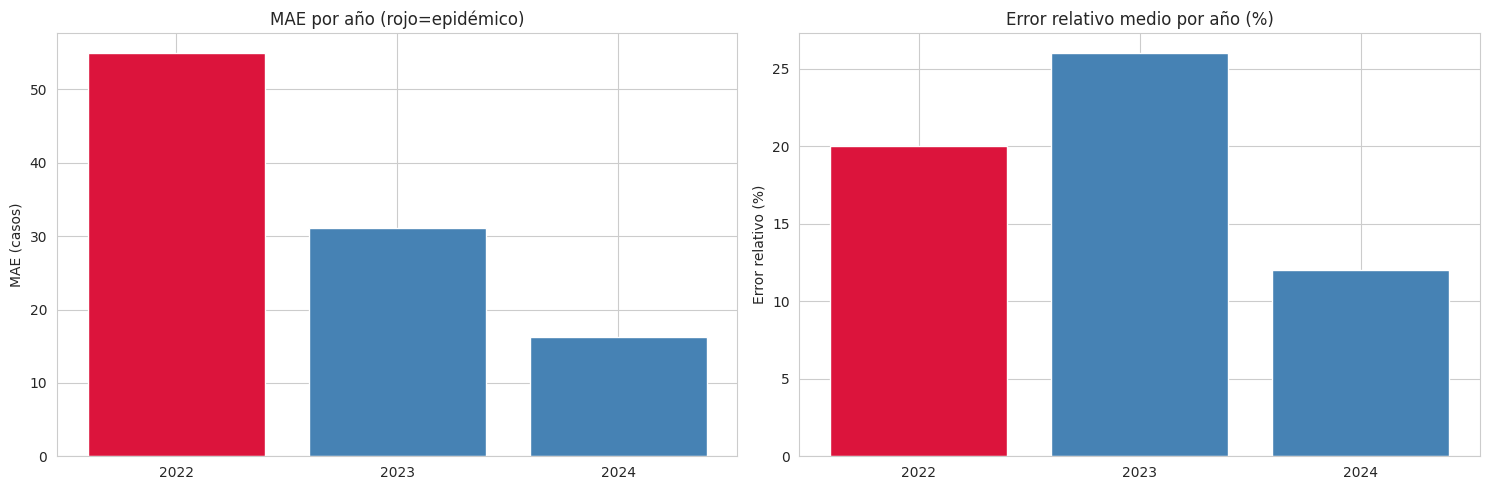

In [3]:
equidad_temporal = test_eval.groupby('anio_epi').agg(
    semanas=('casos_dengue','count'),
    casos_promedio=('casos_dengue','mean'),
    MAE=('error_abs','mean'),
    error_rel_medio=('error_rel','mean'),
).round(2)
equidad_temporal['tipo'] = ['Epidémico' if a==2022 else 'Tranquilo' for a in equidad_temporal.index]
print('=== EQUIDAD TEMPORAL ===')
print(equidad_temporal.to_string())

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(equidad_temporal.index.astype(str), equidad_temporal['MAE'],
            color=['crimson' if t=='Epidémico' else 'steelblue' for t in equidad_temporal['tipo']])
axes[0].set_title('MAE por año (rojo=epidémico)'); axes[0].set_ylabel('MAE (casos)')
axes[1].bar(equidad_temporal.index.astype(str), equidad_temporal['error_rel_medio']*100,
            color=['crimson' if t=='Epidémico' else 'steelblue' for t in equidad_temporal['tipo']])
axes[1].set_title('Error relativo medio por año (%)'); axes[1].set_ylabel('Error relativo (%)')
plt.tight_layout(); plt.show()

**Interpretación:** El MAE absoluto suele ser mayor en años epidémicos (más casos = másmargen de error absoluto), pero lo importante es el ERROR RELATIVO: si es similar entre años,el modelo es equitativo temporalmente. Si el error relativo se dispara en años de brote, elmodelo sería menos confiable justo cuando más se necesita.

## 4. Equidad estacional: temporada alta vs baja

In [4]:
test_eval['temporada'] = np.where(test_eval['semana_epi'].between(18,43),
                                   'Lluviosa (alta)', 'Seca (baja)')
equidad_estacional = test_eval.groupby('temporada').agg(
    semanas=('casos_dengue','count'),
    casos_promedio=('casos_dengue','mean'),
    MAE=('error_abs','mean'),
    error_rel_medio=('error_rel','mean'),
).round(2)
print('=== EQUIDAD ESTACIONAL ===')
print(equidad_estacional.to_string())

# ¿El modelo subestima los picos? (crítico para alertas tempranas)
test_eval['sesgo'] = test_eval['prediccion'] - test_eval['casos_dengue']  # negativo = subestima
print(f'\nSesgo promedio en temporada alta: {test_eval[test_eval["temporada"]=="Lluviosa (alta)"]["sesgo"].mean():.1f}')
print(f'Sesgo promedio en temporada baja: {test_eval[test_eval["temporada"]=="Seca (baja)"]["sesgo"].mean():.1f}')
print('(Sesgo negativo = el modelo SUBESTIMA los casos, lo cual es riesgoso para alertas)')

=== EQUIDAD ESTACIONAL ===
                 semanas  casos_promedio    MAE  error_rel_medio
temporada                                                       
Lluviosa (alta)       78          254.47  39.98             0.16
Seca (baja)           78          141.45  28.16             0.22

Sesgo promedio en temporada alta: 12.0
Sesgo promedio en temporada baja: -7.4
(Sesgo negativo = el modelo SUBESTIMA los casos, lo cual es riesgoso para alertas)


## 5. Equidad de magnitud: ¿acierta igual en semanas altas vs bajas?

=== EQUIDAD DE MAGNITUD ===
             semanas  casos_promedio    MAE  error_rel_medio
nivel_casos                                                 
Bajo              39           78.21  32.35             0.34
Medio-bajo        39          125.18  17.93             0.14
Medio-alto        39          180.72  23.92             0.13
Alto              39          407.74  62.09             0.16


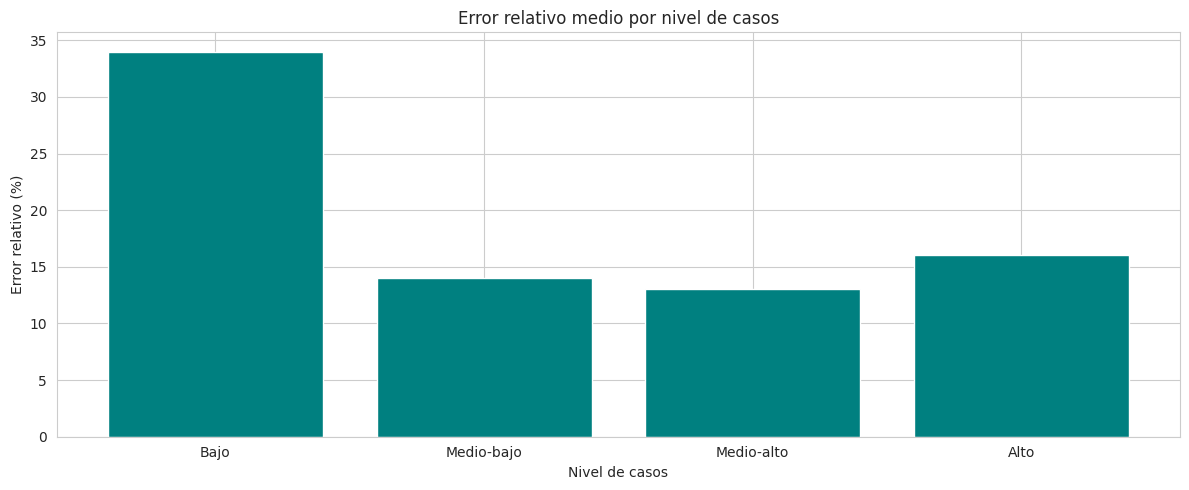

In [5]:
# Dividir en cuartiles según el número real de casos
test_eval['nivel_casos'] = pd.qcut(test_eval['casos_dengue'], q=4,
                                     labels=['Bajo','Medio-bajo','Medio-alto','Alto'])
equidad_magnitud = test_eval.groupby('nivel_casos', observed=True).agg(
    semanas=('casos_dengue','count'),
    casos_promedio=('casos_dengue','mean'),
    MAE=('error_abs','mean'),
    error_rel_medio=('error_rel','mean'),
).round(2)
print('=== EQUIDAD DE MAGNITUD ===')
print(equidad_magnitud.to_string())

plt.figure(figsize=(12, 5))
x = range(len(equidad_magnitud))
plt.bar(x, equidad_magnitud['error_rel_medio']*100, color='teal')
plt.xticks(x, equidad_magnitud.index)
plt.title('Error relativo medio por nivel de casos')
plt.ylabel('Error relativo (%)'); plt.xlabel('Nivel de casos')
plt.tight_layout(); plt.show()

**Interpretación:** Si el error relativo es mucho mayor en el nivel "Alto", el modelotiene dificultad justo con las semanas de mayor transmisión, que son las más críticas para larespuesta sanitaria. Idealmente el error relativo debería ser parejo entre niveles.

## 6. Análisis del tipo de error: ¿sobreestima o subestima?

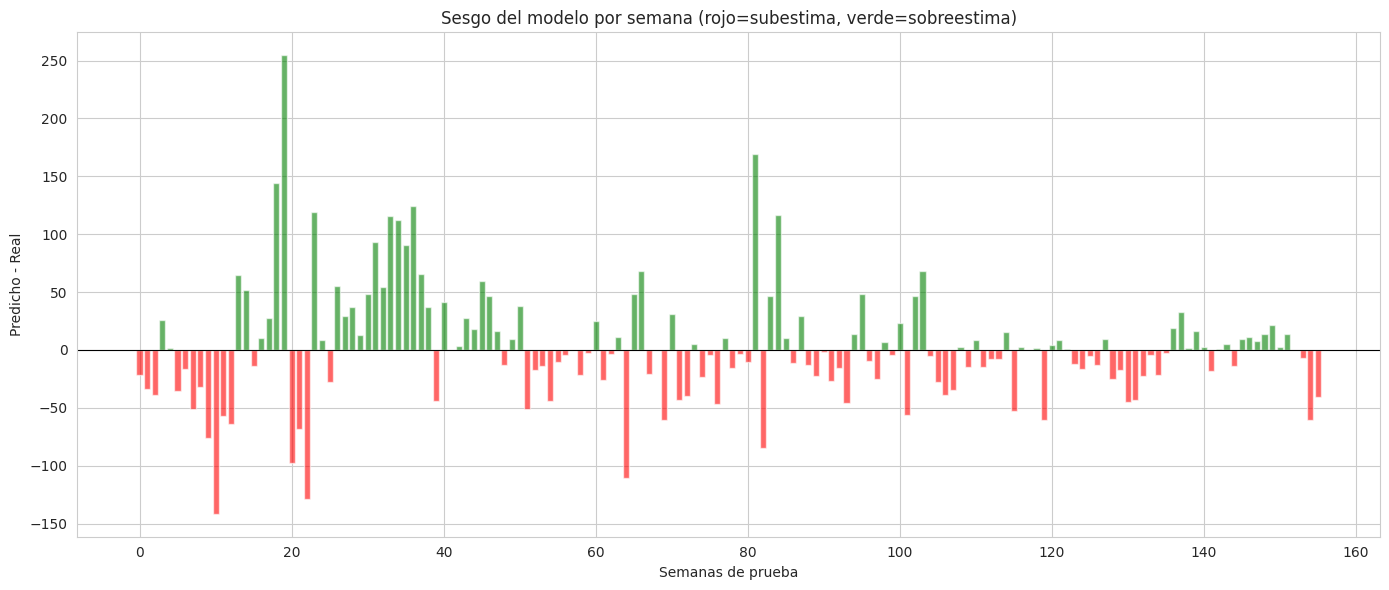

Semanas subestimadas (riesgo de no alertar): 80 (51%)
Semanas sobreestimadas (falsa alarma): 76 (49%)


In [6]:
# En salud pública, subestimar es más peligroso que sobreestimar
# (subestimar = no alertar de un brote que sí ocurre)
plt.figure(figsize=(14, 6))
test_eval_sorted = test_eval.sort_values(['anio_epi','semana_epi']).reset_index(drop=True)
test_eval_sorted['idx'] = range(len(test_eval_sorted))
colores = ['red' if s < 0 else 'green' for s in test_eval_sorted['sesgo']]
plt.bar(test_eval_sorted['idx'], test_eval_sorted['sesgo'], color=colores, alpha=0.6)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Sesgo del modelo por semana (rojo=subestima, verde=sobreestima)')
plt.xlabel('Semanas de prueba'); plt.ylabel('Predicho - Real')
plt.tight_layout(); plt.show()

n_subestima = (test_eval['sesgo'] < 0).sum()
n_sobre = (test_eval['sesgo'] >= 0).sum()
print(f'Semanas subestimadas (riesgo de no alertar): {n_subestima} ({n_subestima/len(test_eval)*100:.0f}%)')
print(f'Semanas sobreestimadas (falsa alarma): {n_sobre} ({n_sobre/len(test_eval)*100:.0f}%)')

## 7. Reflexión: equidad geográfica (conceptual)El modelo actual opera a **nivel nacional**, lo que implica una limitación de equidad importanteque debe documentarse:**El promedio nacional oculta desigualdades entre departamentos.** Un modelo que predice bienel total del país puede estar fallando en departamentos específicos. Por ejemplo, si San Salvadorconcentra la mayoría de los casos, el modelo se ajustará principalmente a su comportamiento,y podría ser menos preciso para departamentos pequeños o rurales.**Implicaciones de equidad en salud pública:**- Un brote localizado en un departamento con poca población podría "diluirse" en el promedio  nacional y no generar alerta, dejando a esa población desatendida.- Los departamentos con menor capacidad de vigilancia (posiblemente los más rurales y pobres)  podrían estar subrepresentados en los datos, perpetuando desigualdades.- Un modelo nacional favorece implícitamente a las zonas más pobladas, que dominan las cifras.**Recomendación:** Para un despliegue equitativo, el modelo debería complementarse con versionesdepartamentales (como el enfoque explorado inicialmente), garantizando que cada territorio recibaatención proporcional a su riesgo real, no a su peso en el promedio nacional.

## 8. Conclusiones del análisis de fairnessDocumenta con los resultados obtenidos:### Equidad temporal- MAE en año epidémico (2022): ___ vs años tranquilos: ___- Error relativo: ¿es equitativo entre años? _____### Equidad estacional- ¿El modelo subestima los picos de temporada alta? _____- Implicación: subestimar en temporada alta es riesgoso (no alertaría brotes)### Equidad de magnitud- ¿El error relativo es parejo entre niveles de casos? _____- ¿Tiene dificultad con las semanas de mayor transmisión? _____### Tipo de error (sesgo)- % de semanas subestimadas vs sobreestimadas: ___- En salud pública, la subestimación es más grave (riesgo de no alertar)### Equidad geográfica- El modelo nacional oculta desigualdades departamentales- Recomendación: complementar con modelos departamentales para equidad territorial### Reflexión ética general- El modelo es una herramienta de APOYO, no un sustituto del criterio epidemiológico- Las decisiones de salud que afectan poblaciones vulnerables no deben automatizarse por completo- La transparencia (SHAP) permite auditar por qué el modelo predice lo que predice